In [1]:
import matplotlib as mpl
import happi
import numpy as np
import matplotlib.pyplot as plt

jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd
jet_vals = jetcmap(np.arange(9)) #extract those values as an array 
jet_vals[0] = [1.0, 1, 1.0, 1] #change the first value 
jet_vals[8] = [0.0, 0, 0.0, 1] #change the first value 
newcmap = mpl.colors.LinearSegmentedColormap.from_list("mine", jet_vals) 

from matplotlib import font_manager

font_dirs = ['/Users/yao/Documents/Calibri and Cambria Fonts/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Calibri'

plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=14)
plt.rc('legend', fontsize=12)


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_73162/3970302568.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd


In [2]:
# energy spectra with errorbars

# averaged over 6 shots

data_directory = '/Users/yao/Nextcloud/PROJECTS/Vulcan/Double_Shock_Colliding/'
data_file_double = 'double_spectra_combined_sigma.txt'
data_file_single = 'single_spectra_combined_sigma.txt'

ene_exp_db = np.loadtxt(data_directory+data_file_double,usecols=0) # in keV
num_exp_db = np.loadtxt(data_directory+data_file_double,usecols=1) # in part/(MeV.sr)
err_exp_db = np.loadtxt(data_directory+data_file_double,usecols=2) # in keV

ene_exp_sg = np.loadtxt(data_directory+data_file_single,usecols=0) # in keV
num_exp_sg = np.loadtxt(data_directory+data_file_single,usecols=1) # in part/(MeV.sr)
err_exp_sg = np.loadtxt(data_directory+data_file_single,usecols=2) # in keV


In [3]:
def spect_load_1d_iter(wkdir,iteration,species,xmin,xmax):
    """
    Inputs ----
    wkdir      : string, data directory
    iteration  : int,    number of timesteps used 
    species    : int,    which species you want to plot
                         according to your own diagnostic in the Namelist
    xmin, xmax : float,  spatial selections, NOTE: in unit of de
    
    Outputs ---
    ekin       : float,  x-axis, energy(E) in MeV
    num        : float,  y-axis, E \frac{dN}{dE} \frac{1}{N}
                                 N  is the total number of particles
                                 dN is the number of particles in each energy range (dE)
                                 dE is the energy range
    simu_time  : float,  simulation time
    """
    S = happi.Open(wkdir)                        # No need to open the data again.
    dt = S.namelist.d_t                            # get simulation timestep
    ts = S.ParticleBinning(species).getTimesteps() # get all the timesteps available for this diag.
    # iteration = int(ts[-2] * time)                 # choose the time you want by a factor of [0,1]*T_end
    simu_time = iteration * dt / wr                # convert it into real unit
    pb = S.ParticleBinning(species).get(iteration) # get the diag. data from the chosen timestep
    
    xx   = pb['x'] * de * 1e3                      # get position information and convert the unit to mm
    ekin = pb['ekin'] * 0.511                      # get energy information (E) and convert the unit to MeV -- the x-axis
    data = pb['data'][0]                           # get the particle number information
    data_selected = data[(xx>xmin) & (xx<xmax),:]  # select particle number according to position
                                                   # for our case now, this doesn't make much difference.
    
    data_ekin = np.sum(data_selected,axis=0)       # dN, ?? can't remember... you might want to check what it does
    dE = ekin[1]-ekin[0]                           # dE, energy range
    total_weight = np.sum(data)                    # N, total number of the selected portion
    num = data_ekin * ekin / total_weight / dE     # E \frac{dN}{dE} \frac{1}{N} -- the y-axis
    
    return ekin, num, simu_time

In [4]:
wkdir = [
    # '/Users/yao/Documents/Data/SS_9_r*/', # v = 3000 km/s
    # '/Users/yao/Documents/Data/DS_9_r*/', 
    # '/Users/yao/Documents/Data/Vulcan2023/SS_12_v2000_r*/', # the one presented in the manuscript 21/07/2025
    # '/Users/yao/Documents/Data/Vulcan2023/DS_12_v2000_r*/',
    '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r*/',
    '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r*/', # the one presented in the manuscript
    '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r*/', 
    # '/Users/yao/Documents/Data/v2500/DS_11_v2500_r*/', # the one presented in the manuscript
    # '/Users/yao/Desktop/Data/SS_2v_0_r*/' # single shock with double shock velocity
    # '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_v2500_Bamb_r*/', # double shock with B-field only in the ambient plasmas 
    # '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_v2500_Bamb/', # single shock with B-field only in the ambient plasmas     
    # '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_v2500_NoAmb_r*', # double shock with no ambient plasma
    # '/Users/yao/Desktop/Data/DS_10_r*/', 
    # '/Users/yao/Desktop/Data/SS_velocities/SS_t5/',   # test 4 -> larger box size
    # '/Users/yao/Desktop/Data/SS_t3000_Nia_select_r1/',
    # '/Users/yao/Nextcloud/PROJECTS/Vulcan/RAL_August2023/Archive/'
    ]

In [5]:
S0 = happi.Open(wkdir[0], reference_angular_frequency_SI = 56375055300167.87)
S1 = happi.Open(wkdir[1], reference_angular_frequency_SI = 56375055300167.87)
S2 = happi.Open(wkdir[2], reference_angular_frequency_SI = 56375055300167.87)
# S3 = happi.Open(wkdir[3], reference_angular_frequency_SI = 56375055300167.87)
# S4 = happi.Open(wkdir[4], reference_angular_frequency_SI = 56375055300167.87)

Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/

In [6]:
# prepare constants, units

me = 9.1e-31
mp = 1836.*me
qe = 1.6e-19
ep = 8.9e-12  # epsilon_0
c  = 3.0e8
wr = S0.namelist.w_r
de = c / wr
Lx = S0.namelist.L_x.real * de * 1e3      # in mm
dx = S0.namelist.d_x * de * 1e3           # in mm

Te = S0.namelist.T_e * 511.e3             # in eV
ne = 1.0e18                              # in cm-3
ld = 7.43e2 * Te**0.5 * ne**(-0.5) * 10. # in mm
dt = S0.namelist.d_t

B0 = S0.namelist.B_z * (me * wr / qe)
wc = qe * B0 / me

# conversion constants for fields and momentum (when taken from TrackParticle)
kE = me*c*wr/qe  # V/m
kp = me*c        # kg m/s
kB = me*wr/qe    # T
conv_MeV_J = 10**6*qe

In [7]:
# num = 130 # 4 ns
num = 130 # last timestep for DS_v2500_r0
time_snap = S1.ParticleBinning(2).getTimesteps()[num]
time_ns = S1.ParticleBinning(2,units=['ns']).getTimes()[num]
print(time_ns)

# ekin2, num2, t_end2 = spect_load_1d_iter(wkdir[2], time_snap, 2, 0.0, Lx)
ekin1, num1, t_end1 = spect_load_1d_iter(wkdir[1], time_snap, 2, 0.0, Lx)
ekin0, num0, t_end0 = spect_load_1d_iter(wkdir[0], time_snap, 2, 0.0, Lx)

3.8431536580568975
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics


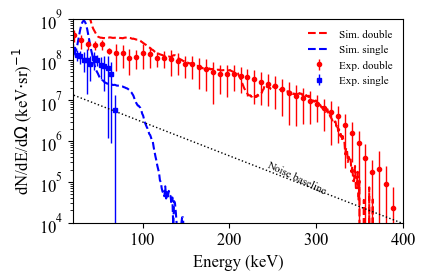

In [8]:
width  = 3.14 *1.5 # single column, 8cm
height = width / 1.618
fig, ax = plt.subplots()

plt.ticklabel_format(axis='both', style='sci',useMathText=True)

fig.subplots_adjust(left=.2, bottom=.2, right=.9, top=.9)

# ax.set_xscale('log')
ax.set_yscale('log')

ax.errorbar(ene_exp_db[0:-1:8], num_exp_db[0:-1:8]/1e3, yerr=err_exp_db[0:-1:8]/1e3, 
            fmt='or',markersize=3,
            ecolor='r',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. double')

ax.errorbar(ene_exp_sg[0:-1:4], num_exp_sg[0:-1:4]/1e3, yerr=err_exp_sg[0:-1:4]/1e3, 
            fmt='sb',markersize=3,
            ecolor='b',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. single')

# ax.plot(ekin3, num3, '-k',  label='Bz=0', lw=1.0)
ax.plot(ekin1*1e3, num1*3e9, '--r',  label='Sim. double', lw=1.5)
ax.plot(ekin0*1e3, num0*7e8, '--b',  label='Sim. single', lw=1.5)

# ax.plot(ekin2*1e3, num2*1e12, '--k',  label='Sim. ssv2 at {:.1f} ns'.format(time_ns), lw=1.5)

# ax.plot(ekin2, num2, '-g',  label='Bz=17T', lw=1.0)
# ax.plot(ekin0, num0, '-y',  label='Shock Width=di~200um', lw=1.0)


ax.tick_params(axis='both',which='major', direction='out',labelsize=12)
ax.minorticks_off()

ax.set_xlabel('Energy (keV)',fontsize=12)
# ax.set_ylabel(r'$E\frac{dN}{dE}\frac{1}{N}$',fontsize=12)
# ax.set_ylabel(r'Part./(keV$\cdot$sr)',fontsize=12)
ax.set_ylabel(r'dN/dE/d$\Omega$ (keV$\cdot$sr)$^{-1}$',fontsize=12)


ax.set_xlim([20, 400])
# formatter = ScalarFormatter()
# formatter.set_scientific(False)
# ax.xaxis.set_major_formatter(formatter)
# ax.set_xticks([0.02, 0.05, 0.08])
# ax.set_xticklabels([0.01, 0.05, 0.10],fontsize=8)


ax.set_ylim([1e4, 1e9])
# ax.set_yticks([1, 0.01, 0.0001])

def func(x,kbT):
    edrift = 0.
    return x*np.sqrt(x)*np.exp(-(x-edrift)**2/kbT) 

index = (ekin0 < 300/1e3)*(ekin0 > 15.0/1e3)
# popt, pcov = curve_fit(func, ekin0[index], num0[index])
# print(popt,pcov)
# y2 = func(ekin0[index], 100.0/1e6)
# ax.plot(ekin0[index], y2*4e3, 'r--',label='100eV')
y3 = func(ekin0[index], 250.0/1e6)
# ax.semilogy(ekin0[index]*1e3, y3*1e15, 'c--',lw=1.0, label='Thermal 250 eV')

energy_range = np.linspace(1,500)
# noise = 33249*(energy_range*1e-3)**(-2.6215)
# noise_de = noise[:-1]/((energy_range[1:]-energy_range[0:-1])/1e0)
noise_base = 10**(-0.0083*energy_range+10.3)
# plt.loglog(energy_range[:-1], noise_de*1e2, '--c', label='noise')
ax.semilogy(energy_range, noise_base/1e3, ':k', lw=1.0)#,label='noise')
x_noise_label = 275
y_noise_label = 10**(-0.0083*x_noise_label+10.3)/1e3
p1 = ax.transData.transform((x_noise_label-50, 10**(-0.0083*(x_noise_label-50)+10.3)/1e3))
p2 = ax.transData.transform((x_noise_label+50, 10**(-0.0083*(x_noise_label+50)+10.3)/1e3))
noise_label_angle = np.degrees(np.arctan2(*(p2-p1)[::-1]))
ax.text(x_noise_label, y_noise_label, 'Noise baseline', color='k', fontsize=8,
        rotation=noise_label_angle, rotation_mode='anchor', ha='center', va='bottom')

leg = ax.legend(loc='best', numpoints=1, fancybox=False, fontsize=8, frameon=False)
leg._legend_box.align = "right"
# ax.grid(which='both')
fig.set_size_inches(width, height)
plt.show()

### note that here the simulation data used is 2500 km/s cases.


In [9]:
## Here, we add the 2D case with 2500 km/s shock velocity, which is the one presented in the manuscript.
## 28/04/2026

# prepare the simulation data

wr = S2.namelist.w_r
de = c / wr
Lx = S2.namelist.L_x.real * de * 1e3      # in mm
dx = S2.namelist.d_x * de * 1e3           # in mm

print('Lx = {:.1f} mm, dx = {:.2f} um'.format(Lx, dx*1e3))


Lx = 21.8 mm, dx = 1.06 um


In [15]:
## Here, we add the 2D case with 2500 km/s shock velocity, which is the one presented in the manuscript.
## 28/04/2026

# prepare the simulation data

# num = 130 # 4 ns
num = 89 # last timestep for double shock case, which is 3.68 ns
time_snap = S2.ParticleBinning(2).getTimesteps()[num]
time_ns = S2.ParticleBinning(2,units=['ns']).getTimes()[num]
print(time_ns)

ekin2, num2, t_end2 = spect_load_1d_iter(wkdir[2], time_snap, 2, 0.0, Lx)
# ekin1, num1, t_end1 = spect_load_1d_iter(wkdir[1], time_snap, 2, 0.0, Lx)
# ekin0, num0, t_end0 = spect_load_1d_iter(wkdir[0], time_snap, 2, 0.0, Lx)

3.6835149676453023
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r1/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r2/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r3/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r4/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r5/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/ds_2d_v2500_t2_r6_break/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics


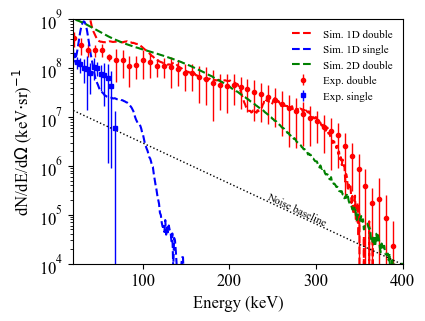

In [18]:
## Here, we add the 2D case with 2500 km/s shock velocity, which is the one presented in the manuscript.
## 28/04/2026

width  = 3.14 *1.5 # single column, 8cm
height = width / 1.618 * 1.2
fig, ax = plt.subplots()

# plt.ticklabel_format(axis='both', style='sci',useMathText=True)

fig.subplots_adjust(left=.2, bottom=.2, right=.9, top=.9)

# ax.set_xscale('log')
ax.set_yscale('log')

ax.errorbar(ene_exp_db[0:-1:8], num_exp_db[0:-1:8]/1e3, yerr=err_exp_db[0:-1:8]/1e3, 
            fmt='or',markersize=3,
            ecolor='r',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. double')

ax.errorbar(ene_exp_sg[0:-1:4], num_exp_sg[0:-1:4]/1e3, yerr=err_exp_sg[0:-1:4]/1e3, 
            fmt='sb',markersize=3,
            ecolor='b',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. single')

# ax.plot(ekin3, num3, '-k',  label='Bz=0', lw=1.0)
ax.plot(ekin1*1e3, num1*3e9, '--r',  label='Sim. 1D double', lw=1.5)
ax.plot(ekin0*1e3, num0*7e8, '--b',  label='Sim. 1D single', lw=1.5)
ax.plot(ekin2*1e3, num2*3e9, '--g',  label='Sim. 2D double', lw=1.5)

# ax.plot(ekin2*1e3, num2*1e12, '--k',  label='Sim. ssv2 at {:.1f} ns'.format(time_ns), lw=1.5)

# ax.plot(ekin2, num2, '-g',  label='Bz=17T', lw=1.0)
# ax.plot(ekin0, num0, '-y',  label='Shock Width=di~200um', lw=1.0)


ax.tick_params(axis='both',which='major', direction='out',labelsize=12)
ax.minorticks_off()

ax.set_xlabel('Energy (keV)',fontsize=12)
# ax.set_ylabel(r'$E\frac{dN}{dE}\frac{1}{N}$',fontsize=12)
# ax.set_ylabel(r'Part./(keV$\cdot$sr)',fontsize=12)
ax.set_ylabel(r'dN/dE/d$\Omega$ (keV$\cdot$sr)$^{-1}$',fontsize=12)


ax.set_xlim([20, 400])
# formatter = ScalarFormatter()
# formatter.set_scientific(False)
# ax.xaxis.set_major_formatter(formatter)
# ax.set_xticks([0.02, 0.05, 0.08])
# ax.set_xticklabels([0.01, 0.05, 0.10],fontsize=8)


ax.set_ylim([1e4, 1e9])
# ax.set_yticks([1, 0.01, 0.0001])

def func(x,kbT):
    edrift = 0.
    return x*np.sqrt(x)*np.exp(-(x-edrift)**2/kbT) 

index = (ekin0 < 300/1e3)*(ekin0 > 15.0/1e3)
# popt, pcov = curve_fit(func, ekin0[index], num0[index])
# print(popt,pcov)
# y2 = func(ekin0[index], 100.0/1e6)
# ax.plot(ekin0[index], y2*4e3, 'r--',label='100eV')
y3 = func(ekin0[index], 250.0/1e6)
# ax.semilogy(ekin0[index]*1e3, y3*1e15, 'c--',lw=1.0, label='Thermal 250 eV')

energy_range = np.linspace(1,500)
# noise = 33249*(energy_range*1e-3)**(-2.6215)
# noise_de = noise[:-1]/((energy_range[1:]-energy_range[0:-1])/1e0)
noise_base = 10**(-0.0083*energy_range+10.3)
# plt.loglog(energy_range[:-1], noise_de*1e2, '--c', label='noise')
ax.semilogy(energy_range, noise_base/1e3, ':k', lw=1.0)#,label='noise')
x_noise_label = 275
y_noise_label = 10**(-0.0083*x_noise_label+10.3)/1e3
p1 = ax.transData.transform((x_noise_label-50, 10**(-0.0083*(x_noise_label-50)+10.3)/1e3))
p2 = ax.transData.transform((x_noise_label+50, 10**(-0.0083*(x_noise_label+50)+10.3)/1e3))
noise_label_angle = np.degrees(np.arctan2(*(p2-p1)[::-1]))
ax.text(x_noise_label, y_noise_label, 'Noise baseline', color='k', fontsize=8,
        rotation=noise_label_angle, rotation_mode='anchor', ha='center', va='bottom')

leg = ax.legend(loc='best', numpoints=1, fancybox=False, fontsize=8, frameon=False)
leg._legend_box.align = "right"
# ax.grid(which='both')
fig.set_size_inches(width, height)
# plt.show()
fig.savefig('/Users/yao/Desktop/energy_spectrum_v2500_2D_280426.pdf', dpi=600)
fig.savefig('/Users/yao/Desktop/energy_spectrum_v2500_2D_280426.png', dpi=600)


### note that here the simulation data used is 2500 km/s cases.


In [20]:
import numpy as np

# load data (E_keV, dN/dE [protons/MeV/sr], sigma)
E_keV, dNdE_perMeV_per_sr, _ = np.loadtxt(data_directory+data_file_double,
                                          usecols=(0,1,2), unpack=True)

# E_keV, dNdE_perMeV_per_sr, _ = np.loadtxt(data_directory+data_file_single,
#                                           usecols=(0,1,2), unpack=True)


# convert dN/dE to per keV per sr
dNdE_perkeV_per_sr = dNdE_perMeV_per_sr / 1e3

# constants
keV_to_J   = 1.602176634e-16   # 1 keV  → Joule
e_charge   = 1.602176634e-19   # proton charge in Coulombs
Omega_sr   = 2.0 * np.pi       # solid angle (2π sr)

# integrals
W_keV_sr = np.trapz(E_keV * dNdE_perkeV_per_sr, E_keV)
W_J      = W_keV_sr * keV_to_J * Omega_sr

N_sr     = np.trapz(dNdE_perkeV_per_sr, E_keV)
N_total  = N_sr * Omega_sr
Q_C      = N_total * e_charge           # total charge in Coulombs

# output
print("Total energy [mJ] =", W_J*1e3)
print("Total protons    =", N_total)
print("Total charge [nC] =", Q_C*1e9)

Total energy [mJ] = 1.5228305243559521
Total protons    = 124152202791.40807
Total charge [nC] = 19.891375837202354


In [21]:
import numpy as np

# load data (E_keV, dN/dE [protons/MeV/sr], sigma)
# E_keV, dNdE_perMeV_per_sr, _ = np.loadtxt(data_directory+data_file_double,
#                                           usecols=(0,1,2), unpack=True)

E_keV, dNdE_perMeV_per_sr, _ = np.loadtxt(data_directory+data_file_single,
                                          usecols=(0,1,2), unpack=True)


# convert dN/dE to per keV per sr
dNdE_perkeV_per_sr = dNdE_perMeV_per_sr / 1e3

# constants
keV_to_J   = 1.602176634e-16   # 1 keV  → Joule
e_charge   = 1.602176634e-19   # proton charge in Coulombs
Omega_sr   = 2.0 * np.pi       # solid angle (2π sr)

# integrals
W_keV_sr = np.trapz(E_keV * dNdE_perkeV_per_sr, E_keV)
W_J      = W_keV_sr * keV_to_J * Omega_sr

N_sr     = np.trapz(dNdE_perkeV_per_sr, E_keV)
N_total  = N_sr * Omega_sr
Q_C      = N_total * e_charge           # total charge in Coulombs

# output
print("Total energy [mJ] =", W_J*1e3)
print("Total protons    =", N_total)
print("Total charge [nC] =", Q_C*1e9)

Total energy [mJ] = 0.08621481098303237
Total protons    = 15408569488.06186
Total charge [nC] = 2.468724999713805


In [22]:
num = 140 
time_snap = S1.ParticleBinning(2).getTimesteps()[num]
time_ns = S1.ParticleBinning(2,units=['ns']).getTimes()[num]
print(time_ns)

ekin1, num1, t_end1 = spect_load_1d_iter(wkdir[1], time_snap, 2, 0.0, Lx)
ekin0, num0, t_end0 = spect_load_1d_iter(wkdir[0], time_snap, 2, 0.0, Lx)

4.138780862522813
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/DS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r0/'
Loaded simulation '/Users/yao/Documents/Data/Vulcan2023/v2500/SS_11_v2500_r1/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics


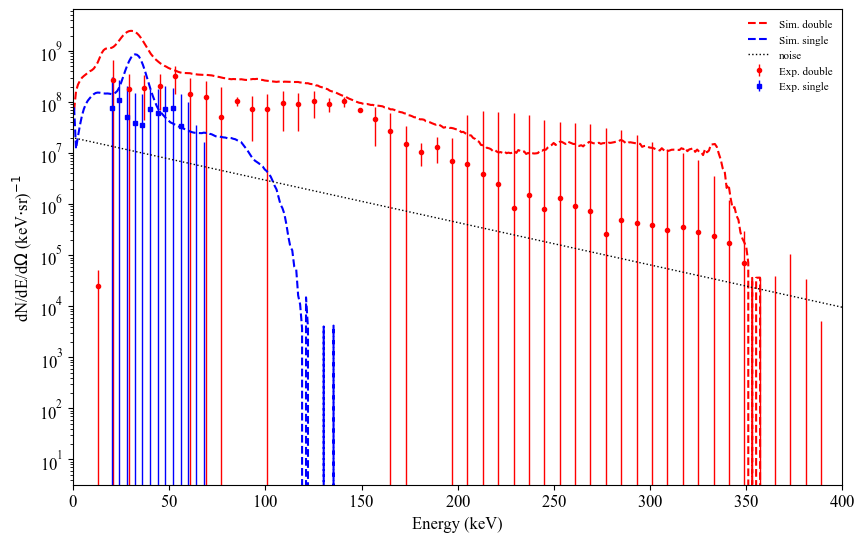

In [24]:
width  = 3.14 *3.5 # single column, 8cm
height = width / 1.618
fig, ax = plt.subplots()

plt.ticklabel_format(axis='both', style='sci',useMathText=True)

fig.subplots_adjust(left=.2, bottom=.2, right=.9, top=.9)

ax.set_yscale('log')

ax.errorbar(ene_exp_db[0:-1:8], num_exp_db[0:-1:8]/1e3, yerr=err_exp_db[0:-1:8]/1e3, 
            fmt='or',markersize=3,
            ecolor='r',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. double')

ax.errorbar(ene_exp_sg[0:-1:4], num_exp_sg[0:-1:4]/1e3, yerr=err_exp_sg[0:-1:4]/1e3, 
            fmt='sb',markersize=3,
            ecolor='b',elinewidth=1.0,
            # capsize=2.0, capthick = 1.0,
            label='Exp. single')

ax.plot(ekin1*1e3, num1*3e9, '--r',  label='Sim. double', lw=1.5)
ax.plot(ekin0*1e3, num0*7e8, '--b',  label='Sim. single', lw=1.5)

ax.tick_params(axis='both',which='major', direction='out',labelsize=12)
ax.minorticks_off()

ax.set_xlabel(r'Energy (keV)',fontsize=12)
ax.set_ylabel(r'dN/dE/d$\Omega$ (keV$\cdot$sr)$^{-1}$',fontsize=12)


ax.set_xlim([0, 400])
# ax.set_ylim([1e5, 1e10])

energy_range = np.linspace(1,500)
noise_base = 10**(-0.0083*energy_range+10.3)
ax.semilogy(energy_range, noise_base/1e3, ':k', lw=1.0)
x_noise_label = 275
y_noise_label = 10**(-0.0083*x_noise_label+10.3)/1e3
p1 = ax.transData.transform((x_noise_label-50, 10**(-0.0083*(x_noise_label-50)+10.3)/1e3))
p2 = ax.transData.transform((x_noise_label+50, 10**(-0.0083*(x_noise_label+50)+10.3)/1e3))
noise_label_angle = np.degrees(np.arctan2(*(p2-p1)[::-1]))
ax.text(x_noise_label, y_noise_label, 'Noise baseline', color='k', fontsize=8,
        rotation=noise_label_angle, rotation_mode='anchor', ha='center', va='bottom')

leg = ax.legend(loc='best', numpoints=1, fancybox=False, fontsize=8, frameon=False)
leg._legend_box.align = "right"
fig.set_size_inches(width, height)
plt.show()

### note that here the simulation data used is 2500 km/s cases.
